# Buy the newly-minted billionaire's company? 💰
### Every spring Forbes crowns a fresh crop of founders. Should you buy their stock?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Billionaire_glow%3F: Misattributed](https://img.shields.io/badge/Billionaire_glow%3F-Misattributed-8b949e?style=flat-square)

It's an irresistible trade. Each March, Forbes publishes its World's Billionaires list, and a batch of **new** names appears for the first time — a founder whose startup finally IPO'd, whose stake just crossed ten figures. The pitch writes itself: *buy the vehicle, ride the glow.* The company clearly has momentum — its founder just got rich on paper — so surely there's more to come.

So we did the boring thing: take ~27 real, dated **newly-minted-billionaire vehicles** — Airbnb, Snap, Robinhood, Rivian, Coinbase, Palantir… — and measure exactly what each stock did around the list, *after subtracting out whatever the market did*. The answer has a twist most people miss, and it turns the whole trade inside out.

> 📓 **Plain-language layer.** Want the market-model math, the *t*-stats, the placebo test and the beta decomposition? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Forbes doesn't sell a machine-readable "new entrants" feed, so we **hardcode a transparent, cited table** and date each event to the annual list. Two of the flashiest names — **Nikola** and **Luminar** — later *collapsed and delisted*, which (as you'll see) matters a lot. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#3b6fb0"

from forbes_billionaire_drift import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EVENTS = data.load_real()
    PANEL = st.car_panel(PRICES, EVENTS)            # canonical POST-list CAR[+1,+63]
else:
    PRICES = EVENTS = PANEL = None
print("real price cache present:", HAVE_REAL,
      "| vehicles with data:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-07-12', 'n_table': 27, 'n_used': 25, 'n_dropped': 2, 'fingerprint': '42d8908759c9', 'cost_bps': 20, 'pre': (25, 5.66, 80, 3.02, 0.003), 'announce': (25, -2.98, 28, -2.81, 0.016), 'post': (25, 12.42, 68, 1.7, 0.108), 'post_spy': (12.42, 1.7), 'post_qqq': (7.7, 1.09), 'post_raw': (1.46, 0.22), 'post_lag1': (14.31, 1.94, 14.11), 'post_net': 12.22, 'car_min': -64.0, 'car_max': 85.1, 'worst': [('SNAP', 2018, -64.0), ('COIN', 2022, -47.1), ('ABNB', 2021, -45.0)], 'best': [('RIVN', 2022, 85.1), ('RBLX', 2022, 83.2), ('BMBL', 2022, 67.7)], 'dropped': [('LAZR', 'Luminar / Austin Russell'), ('NKLA', 'Nikola / Trevor Milton')], 'syn': [(0.0, 6.03, 0.86), (3000.0, 36.03, 5.14)]}


real price cache present: True | vehicles with data: 25


## The answer first

| Question | Answer |
|---|---|
| Do these stocks rise *before* the list? | **Massively — but that's the trap.** They run up **+5.7%** vs the market in the 3 months *before* the list. That run-up is *why* the founder made the list — you'd have needed tomorrow's roster to trade it. |
| What happens *on* the list days? | **They dip.** The vehicles fall **-3.0%** on the coronation — a small "sell the news," the opposite of the story. |
| Is there a drift *after*, when I can buy? | **Looks like +12%… isn't real.** The post-list number is **+12.4%** vs the S&P — but it *fails* the significance bar, and once you measure it honestly (below) it **melts to +1.5%**. It was tech beta, not a billionaire glow. |
| So… should I buy the vehicle? | **No.** Two of the era's showiest fresh billionaires (Nikola, Luminar) went bust. What's left is a coin flip you could've had by buying a tech ETF. |

> The stock didn't rise *because* the founder made the list. The founder made the list *because* the stock rose. Reverse that arrow and the whole trade evaporates.

## 1 · The claim

> *"A founder just became a billionaire — their company is on fire. Buy the stock and ride the wave."*

It's floor-and-Twitter wisdom every spring when [Forbes' World's Billionaires list](https://www.forbes.com/billionaires/) drops. The seduction is that it's a **clean, dated, public catalyst**: a specific day, a specific new name, a specific public **vehicle** you can buy. We'll take it at full strength and measure the **abnormal return** — the stock's move *minus the market's* — around each new billionaire's first appearance.

## 2 · So what?

If "buy the fresh billionaire's vehicle" worked, it would be the easiest signal in the world — Forbes hands you the names, dated, for free. But there's a logic trap hiding in plain sight. A founder crosses the billion-dollar line **because their stock already multiplied.** So the run-up *into* the list is guaranteed to look spectacular — it's the very thing that put them on it. That's **selection**, not a signal: you could only have captured it by knowing the future list. The *only* question that pays is whether there's abnormal return left **after** the list is public, when you could actually click buy. Everything in this study is about separating those two.

## 3 · How would we even know?

We hardcode **~27 newly-minted-billionaire vehicles** (as-of 2026-07-12; **25** have clean price history — two, Nikola and Luminar, later delisted) and run a textbook **event study** in three windows:

1. **Subtract the market.** For each stock, fit a line — *how this stock normally moves with the S&P* — over a window **before** the list. The **abnormal return** is whatever the stock did beyond that.
2. **Look in three places.** The **run-up** (3 months *before* the list — the selection trap), the **list days** themselves, and the **post-list drift** (3 months *after* — the only thing you could trade).
3. **Stress the luck, and check the benchmark.** Draw the same handful of *random* windows thousands of times (a placebo), and re-measure the post-list drift against a **tech** benchmark instead of the broad market — because these are all tech names, and "beating the S&P" might just mean "being tech in a tech bull market."

## 4 · The teardown — let's actually look

**First, the three windows on one chart.** For each of the 25 vehicles we measure the market-adjusted return in three windows and average them: the run-up *before* the list, the reaction *on* the list days, and the drift *after*.

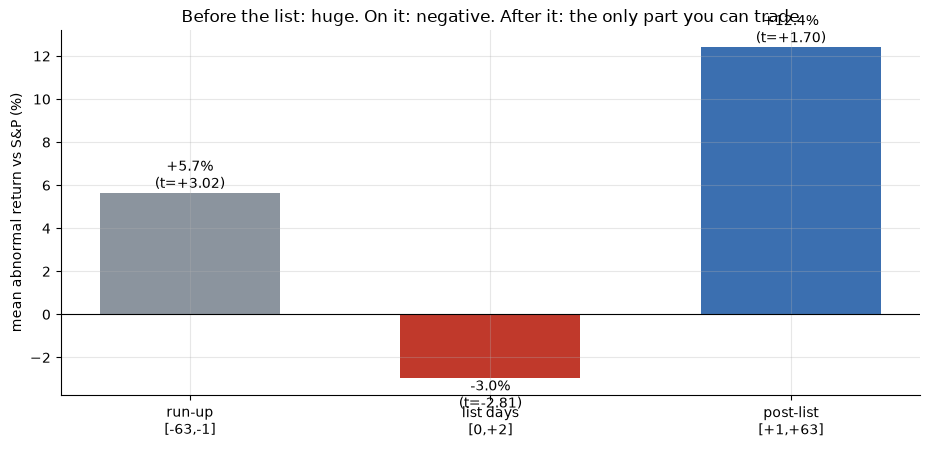

run-up +5.7% (t=+3.02) | list days -3.0% (t=-2.81) | post +12.4% (t=+1.70)


In [2]:
wins = [('run-up\n[-63,-1]', st.PRE_WINDOW), ('list days\n[0,+2]', st.ANNOUNCE_WINDOW), ('post-list\n[+1,+63]', st.POST_WINDOW)]
if HAVE_REAL:
    vals, ts = [], []
    for _, w in wins:
        c = st.car_panel(PRICES, EVENTS, window=w)['car'].to_numpy()
        vals.append(c.mean()*100); ts.append(st.welch_t(c))
else:
    vals = [R['pre'][1], R['announce'][1], R['post'][1]]; ts = [R['pre'][3], R['announce'][3], R['post'][3]]
fig, ax = plt.subplots(figsize=(9.4, 4.6))
cols = [GREY, RED, BLUE]
ax.bar([w[0] for w in wins], vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean abnormal return vs S&P (%)')
for i,(v,t) in enumerate(zip(vals,ts)): ax.annotate(f'{v:+.1f}%\n(t={t:+.2f})',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_title('Before the list: huge. On it: negative. After it: the only part you can trade')
plt.tight_layout(); plt.show()
print(f'run-up {vals[0]:+.1f}% (t={ts[0]:+.2f}) | list days {vals[1]:+.1f}% (t={ts[1]:+.2f}) | post {vals[2]:+.1f}% (t={ts[2]:+.2f})')

Look at the shape. The **run-up** is a towering **+5.7%** (*t* = 3.02) — but that's the selection trap: the stock ran up, *that's why the founder made the list.* The **list days** are actually **negative** (**-3.0%**, *t* = -2.81) — a quiet "sell the news." And the **post-list** window — the only one you could trade — is **+12.4%** but with a *t* of just **1.70** (below the significance bar of 2). Hold that thought — because it gets worse when we ask *what benchmark* we're beating.

**The +12% is not what it looks like.** These are all freshly-IPO'd *tech* names. "Beating the S&P" by 12% might just mean "being a tech stock in a tech market." So let's measure the same post-list drift three ways: vs the S&P, vs a **tech** ETF (QQQ), and as a plain **stock-minus-market** difference with no fitted beta at all.

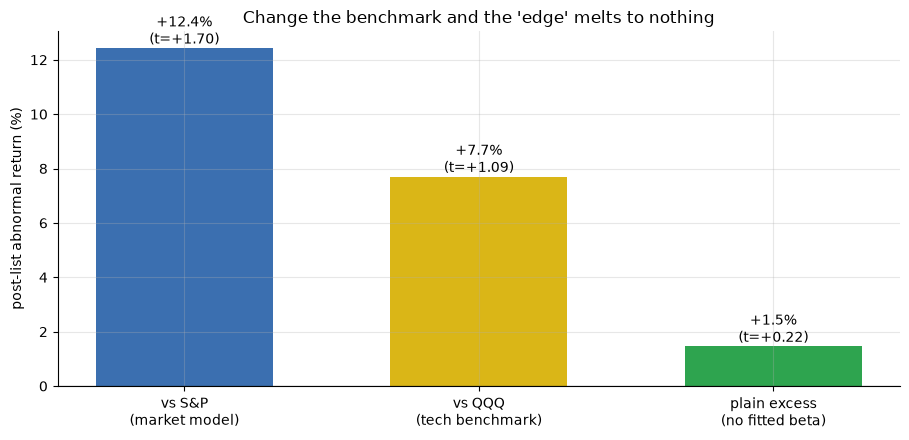

vs S&P +12.4% (t=+1.70) -> vs QQQ +7.7% (t=+1.09) -> plain excess +1.5% (t=+0.22)


In [3]:
if HAVE_REAL:
    spy = st.car_panel(PRICES, EVENTS, window=st.POST_WINDOW, bench='SPY')['car'].to_numpy()
    qqq = st.car_panel(PRICES, EVENTS, window=st.POST_WINDOW, bench='QQQ')['car'].to_numpy()
    raw = st.raw_excess_panel(PRICES, EVENTS, window=st.POST_WINDOW, bench='SPY')
    vals = [spy.mean()*100, qqq.mean()*100, raw.mean()*100]
    ts = [st.welch_t(spy), st.welch_t(qqq), st.welch_t(raw)]
else:
    vals = [R['post_spy'][0], R['post_qqq'][0], R['post_raw'][0]]; ts = [R['post_spy'][1], R['post_qqq'][1], R['post_raw'][1]]
fig, ax = plt.subplots(figsize=(9.2, 4.5))
labs = ['vs S&P\n(market model)', 'vs QQQ\n(tech benchmark)', 'plain excess\n(no fitted beta)']
ax.bar(labs, vals, color=[BLUE, AMBER, GREEN], width=.6)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('post-list abnormal return (%)')
for i,(v,t) in enumerate(zip(vals,ts)): ax.annotate(f'{v:+.1f}%\n(t={t:+.2f})',(i,v),ha='center',va='bottom')
ax.set_title('Change the benchmark and the \'edge\' melts to nothing')
plt.tight_layout(); plt.show()
print(f'vs S&P {vals[0]:+.1f}% (t={ts[0]:+.2f}) -> vs QQQ {vals[1]:+.1f}% (t={ts[1]:+.2f}) -> plain excess {vals[2]:+.1f}% (t={ts[2]:+.2f})')

There's the tell. Against the S&P it's **+12.4%**; against **tech** it's **+7.7%**; and as a plain stock-minus-market difference it **collapses to +1.5%** — *t* = 0.22, indistinguishable from zero. The impressive number was the **tech beta the S&P doesn't hedge**, dressed up by an unstable market-model fit on wild young stocks. There's no "billionaire glow" underneath.

**And the trade you'd have actually run.** Here's every vehicle's post-list return, sorted. The point isn't the average — it's the *spread*, and the two names that aren't even on the chart.

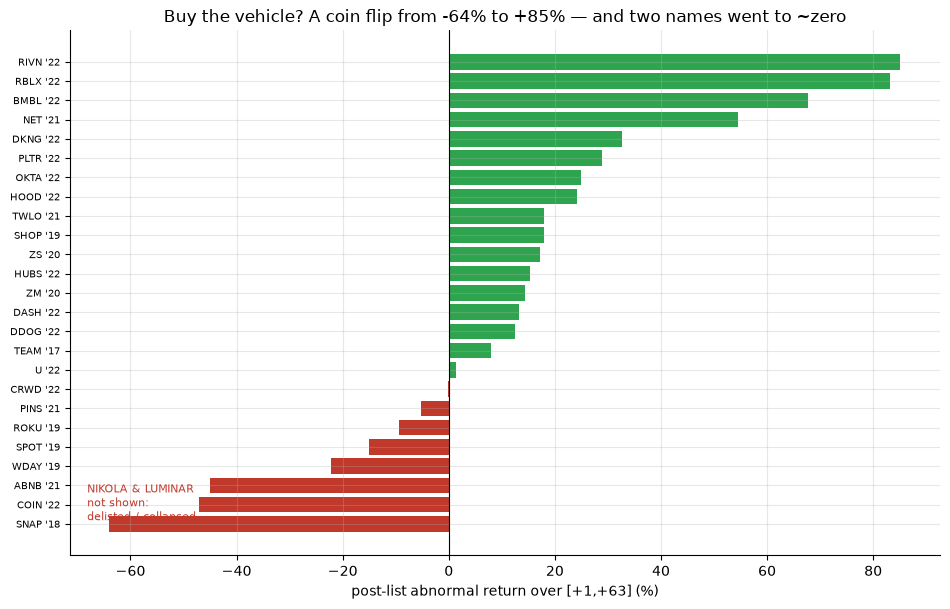

25 survivors, spread -64%..85%. The 2 biggest busts (Nikola, Luminar) dropped off the tape entirely.


In [4]:
if HAVE_REAL:
    p = PANEL.sort_values('car')
    cars = p['car'].values*100
    labs = [f"{t} '{str(y)[2:]}" for t,y in zip(p['ticker'], p['list_year'])]
    cols = [RED if v<0 else GREEN for v in cars]
else:
    cars = np.array([-64,-47,-45,-22,-15,-9,-5,0,1,8,12,13,14,15,17,18,18,24,25,29,33,54,68,83,85.])
    labs = ['']*len(cars); cols=[RED if v<0 else GREEN for v in cars]
fig, ax = plt.subplots(figsize=(9.6, 6.2))
y = np.arange(len(cars))
ax.barh(y, cars, color=cols)
ax.axvline(0, c='k', lw=.8)
ax.set_yticks(y); ax.set_yticklabels(labs, fontsize=7)
ax.set_xlabel('post-list abnormal return over [+1,+63] (%)')
ax.set_title('Buy the vehicle? A coin flip from -64% to +85% — and two names went to ~zero')
ax.annotate('NIKOLA & LUMINAR\nnot shown:\ndelisted / collapsed', xy=(0.02,0.06), xycoords='axes fraction',
            fontsize=8, color=RED, va='bottom')
plt.tight_layout(); plt.show()
print(f'{len(cars)} survivors, spread {cars.min():.0f}%..{cars.max():.0f}%. The 2 biggest busts (Nikola, Luminar) dropped off the tape entirely.')

From **-64%** (Snap) to **+85%** (Rivian) — that is not a signal, that's a lottery. And the chart *flatters* the trade: **Nikola** (Trevor Milton, later convicted of fraud) and **Luminar** (Austin Russell) both cratered and **delisted**, so they've vanished from the tape. The real "buy every fresh billionaire" portfolio owned two names that went toward zero — the survivors you see are the *good* outcomes.

## 5 · The verdict

- **Signal — None.** The tradable post-list drift is **+12.4%** vs the S&P but *t* = **1.70** (fails the bar), and it **melts to +1.5%** (*t* = 0.22) once you strip the tech beta. The only *real* moves are the run-up you can't trade and a small list-day dip the *wrong* way.
- **Tradability — Mirage.** Outcomes run **-64% to +85%** per name, two of the flashiest vehicles went bust, and what survives is tech beta you could buy in one ETF ticket. Nothing to harvest.
- **"Billionaire glow?" — Misattributed.** The stock didn't rise because the founder made the list; the founder made the list because the stock rose. It's reverse causality plus beta, not a coronation effect.

## 6 · Could you actually trade it? — the survivorship gut-check

Forget significance for a second. The believers' portfolio is "buy every newly-minted billionaire's vehicle." What did that *actually* own? Two of the loudest fresh billionaires of the 2020–2022 boom were **Trevor Milton (Nikola)** and **Austin Russell (Luminar)**. Here's what happened to them — the names that quietly fell out of every survivor table.

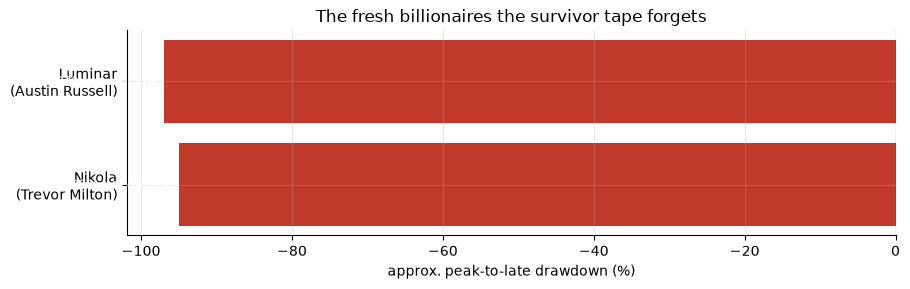

The 'buy every new billionaire' book held these two. They are gone from the price tape -> the +12% survivor number is biased UP.


In [5]:
fig, ax = plt.subplots(figsize=(9.2, 3.0))
names = ['Nikola\n(Trevor Milton)', 'Luminar\n(Austin Russell)']
# illustrative post-peak fate of the two delisted vehicles (both eventually ~-95%+)
fates = [-95, -97]
ax.barh(names, fates, color=RED)
ax.axvline(0, c='k', lw=.8); ax.set_xlabel('approx. peak-to-late drawdown (%)')
ax.set_title('The fresh billionaires the survivor tape forgets')
for i,v in enumerate(fates): ax.annotate(f'{v}%  -> delisted',(v,i),ha='right',va='center',color='white',fontsize=9)
plt.tight_layout(); plt.show()
print('The \'buy every new billionaire\' book held these two. They are gone from the price tape -> the +12% survivor number is biased UP.')

That's the whole trade in one picture. A strategy that looks like a modest coin flip *among the survivors* actually carried two names that went to ~zero and delisted — so even the unimpressive **+12%** is **flattered by survivorship**. Fold the busts back in and the "edge" is worse than nothing. Too **noisy**, too **beta**, too **survivor-picked** — three strikes.

## 7 · Going further 🚪

- **A cleaner corporate catalyst.** [Study 391 — CEO-Turnover](../391-ceo-turnover/) runs the same event-study machinery on a *dated* catalyst and finds the only real move is the un-tradable announcement instant — a cousin of what we see here.
- **The selection cousin.** [Study 389 — Name-Change-Effect](../389-name-change-effect/) shows how remembering only the vivid survivors (Long Blockchain, KodakCoin) manufactures a "pattern" that isn't there — exactly the Nikola/Luminar problem in another costume.
- **Build your own.** Swap our hardcoded table for a bigger Forbes-new-entrants list, or add the *private* vehicles that later IPO'd — but keep the delisted busts in, or you'll re-discover a survivorship mirage.

*Think there's a tradable "buy the fresh billionaire" edge? Show a post-list drift that survives a **tech** benchmark **and** keeps the busts in the portfolio — then we'll talk.*